# Validacao e Otimizacao de Modelos (Semana 13)

## Cross-Validation, GridSearch e como evitar Overfitting

Dataset: **Titanic**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Carregando e preparando o dataset

In [2]:
titanic = sns.load_dataset('titanic')
colunas_usar = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = titanic[colunas_usar].copy()
print(f'Dimensoes: {df.shape}')
print(f'Nulos:\n{df.isnull().sum()}')
df.head()

Dimensoes: (891, 8)
Nulos:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [3]:
X = df.drop(columns=['survived'])
y = df['survived']
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
col_num = ['age', 'sibsp', 'parch', 'fare']
col_cat = ['sex', 'embarked']
col_ord = ['pclass']
print(f'Treino: {X_treino.shape[0]}  |  Teste: {X_teste.shape[0]}')

Treino: 712  |  Teste: 179


In [4]:
preprocessador = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), col_num),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(drop='first'))]), col_cat),
    ('ord', 'passthrough', col_ord)
])
print('Preprocessador pronto.')

Preprocessador pronto.


---
## 2. Modelo padrao (baseline) - Arvore de Decisao sem ajuste

In [5]:
pipe_default = Pipeline([
    ('prep', preprocessador),
    ('modelo', DecisionTreeClassifier(random_state=42))
])
pipe_default.fit(X_treino, y_treino)
y_pred_default = pipe_default.predict(X_teste)
acc_default = accuracy_score(y_teste, y_pred_default)
print(f'Acurácia Arvore padrao (teste): {acc_default:.4f}  ({acc_default*100:.1f}%)')
acc_default_train = accuracy_score(y_treino, pipe_default.predict(X_treino))
print(f'Acurácia Arvore padrao (treino): {acc_default_train:.4f}  ({acc_default_train*100:.1f}%)')
print(f'Diferenca treino-teste: {acc_default_train - acc_default:.4f}  << sinal de overfitting se muito alta')

Acurácia Arvore padrao (teste): 0.8156  (81.6%)
Acurácia Arvore padrao (treino): 0.9831  (98.3%)
Diferenca treino-teste: 0.1675  << sinal de overfitting se muito alta


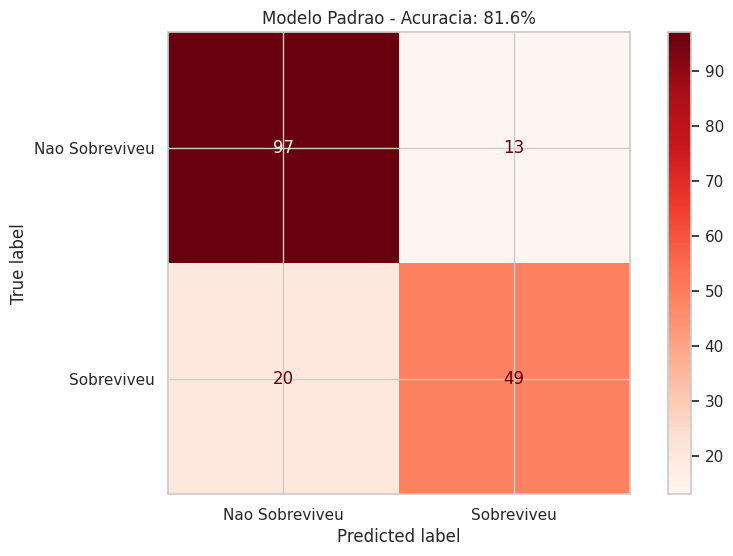

In [6]:
display = ConfusionMatrixDisplay.from_estimator(pipe_default, X_teste, y_teste, cmap='Reds', display_labels=['Nao Sobreviveu', 'Sobreviveu'])
plt.title(f'Modelo Padrao - Acuracia: {acc_default*100:.1f}%')
plt.show()

---
## 3. GridSearchCV - Encontrando os melhores hiperparametros

Vamos testar combinacoes de:
- `max_depth`: 3, 5, 10, 15
- `min_samples_split`: 2, 5, 10
- `criterion`: gini, entropy

In [7]:
pipe = Pipeline([
    ('prep', preprocessador),
    ('modelo', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'modelo__max_depth': [3, 5, 10, 15, None],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__criterion': ['gini', 'entropy']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_treino, y_treino)

print('\nMELHORES HIPERPARAMETROS:')
print(grid.best_params_)
print(f'Melhor score medio (CV): {grid.best_score_:.4f}  ({grid.best_score_*100:.1f}%)')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

MELHORES HIPERPARAMETROS:
{'modelo__criterion': 'gini', 'modelo__max_depth': 5, 'modelo__min_samples_split': 5}
Melhor score medio (CV): 0.8175  (81.7%)


In [8]:
y_pred_grid = grid.predict(X_teste)
acc_grid = accuracy_score(y_teste, y_pred_grid)
print(f'Acurácia Arvore otimizada (teste): {acc_grid:.4f}  ({acc_grid*100:.1f}%)')
print(f'\nComparacao:')
print(f'  Padrao:     {acc_default:.4f}  ({acc_default*100:.1f}%)')
print(f'  Otimizada:  {acc_grid:.4f}  ({acc_grid*100:.1f}%)')
print(f'  Ganho:      {acc_grid - acc_default:+.4f}  (+{(acc_grid - acc_default)*100:.1f} pp)')
print(f'\n{classification_report(y_teste, y_pred_grid, target_names=["Nao Sobreviveu", "Sobreviveu"])}')

Acurácia Arvore otimizada (teste): 0.7821  (78.2%)

Comparacao:
  Padrao:     0.8156  (81.6%)
  Otimizada:  0.7821  (78.2%)
  Ganho:      -0.0335  (+-3.4 pp)

                precision    recall  f1-score   support

Nao Sobreviveu       0.79      0.88      0.83       110
    Sobreviveu       0.77      0.62      0.69        69

      accuracy                           0.78       179
     macro avg       0.78      0.75      0.76       179
  weighted avg       0.78      0.78      0.78       179



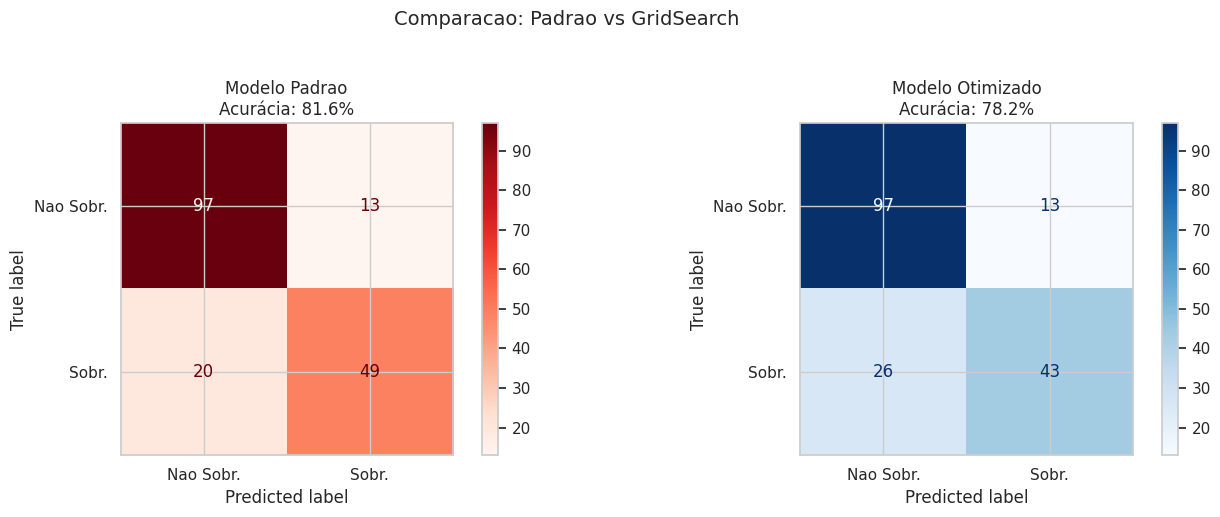

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_estimator(pipe_default, X_teste, y_teste, cmap='Reds', display_labels=['Nao Sobr.', 'Sobr.'], ax=axes[0])
axes[0].set_title(f'Modelo Padrao\nAcurácia: {acc_default*100:.1f}%')
ConfusionMatrixDisplay.from_estimator(grid, X_teste, y_teste, cmap='Blues', display_labels=['Nao Sobr.', 'Sobr.'], ax=axes[1])
axes[1].set_title(f'Modelo Otimizado\nAcurácia: {acc_grid*100:.1f}%')
plt.suptitle('Comparacao: Padrao vs GridSearch', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### Visualizando todos os resultados do GridSearch

In [10]:
resultados_cv = pd.DataFrame(grid.cv_results_)
top10 = resultados_cv[['param_modelo__max_depth', 'param_modelo__min_samples_split',
                        'param_modelo__criterion', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(10)
top10.columns = ['max_depth', 'min_samples_split', 'criterion', 'Score Medio CV', 'Ranking']
top10.reset_index(drop=True)

,max_depth,min_samples_split,criterion,Score Medio CV,Ranking
0,5,10,gini,0.817492,1
1,5,5,gini,0.817492,1
2,5,2,gini,0.816084,3
3,5,5,entropy,0.807673,4
4,5,2,entropy,0.807673,4
5,5,10,entropy,0.807673,4
6,3,10,gini,0.807663,7
7,3,2,gini,0.807663,7
8,3,10,entropy,0.807663,7
9,3,5,gini,0.807663,7


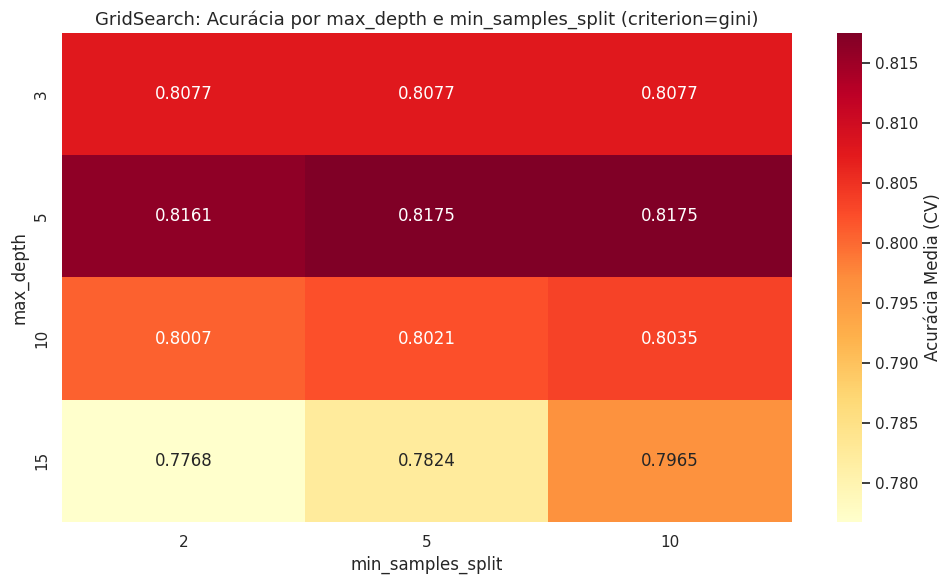

In [11]:
pivot = resultados_cv[resultados_cv['param_modelo__criterion'] == 'gini']
pivot_table = pivot.pivot_table(
    values='mean_test_score',
    index='param_modelo__max_depth',
    columns='param_modelo__min_samples_split'
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'Acurácia Media (CV)'})
plt.title('GridSearch: Acurácia por max_depth e min_samples_split (criterion=gini)', fontsize=13)
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

---
## 4. Experimento 1: Variando o numero de folds (cv=3, cv=5, cv=10)

In [12]:
resultados_folds = []
for n_folds in [3, 5, 10]:
    grid_fold = GridSearchCV(pipe, param_grid, cv=n_folds, scoring='accuracy', n_jobs=-1)
    grid_fold.fit(X_treino, y_treino)
    acc = accuracy_score(y_teste, grid_fold.predict(X_teste))
    resultados_folds.append({'Folds CV': n_folds, 'Melhor Score CV': grid_fold.best_score_,
                             'Acurácia Teste': acc, 'Melhores Params': str(grid_fold.best_params_)})
pd.DataFrame(resultados_folds).set_index('Folds CV')

,Melhor Score CV,Acurácia Teste,Melhores Params
Folds CV,,,
3,0.818831,0.804469,"{'modelo__criterion': 'entropy', 'modelo__max_..."
5,0.817492,0.782123,"{'modelo__criterion': 'gini', 'modelo__max_dep..."
10,0.818838,0.770950,"{'modelo__criterion': 'entropy', 'modelo__max_..."


---
## 5. Experimento 2: GridSearch com Regressao Logistica

In [13]:
pipe_lr = Pipeline([
    ('prep', preprocessador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'modelo__C': [0.01, 0.1, 1, 10, 100],
    'modelo__solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_treino, y_treino)

print('Regressao Logistica - Melhores hiperparametros:')
print(grid_lr.best_params_)
print(f'Melhor score medio (CV): {grid_lr.best_score_:.4f}')

acc_lr = accuracy_score(y_teste, grid_lr.predict(X_teste))
print(f'Acurácia teste: {acc_lr:.4f}  ({acc_lr*100:.1f}%)')
print(f'\nRegressao Logistica otimizada: {acc_lr:.4f}')
print(f'Arvore de Decisao otimizada:    {acc_grid:.4f}')
print(f'Diferenca:                       {acc_lr - acc_grid:+.4f}')

Regressao Logistica - Melhores hiperparametros:
{'modelo__C': 0.1, 'modelo__solver': 'lbfgs'}
Melhor score medio (CV): 0.8105
Acurácia teste: 0.7989  (79.9%)

Regressao Logistica otimizada: 0.7989
Arvore de Decisao otimizada:    0.7821
Diferenca:                       +0.0168


---
## 6. Experimento 3: Overfitting - Modelo padrao vs otimizado (treino vs teste)

In [14]:
modelos = {
    'Padrao (sem limites)': DecisionTreeClassifier(random_state=42),
    'Otimizado (GridSearch)': grid.best_estimator_.named_steps['modelo'],
    'Raso (max_depth=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Profundo (max_depth=20)': DecisionTreeClassifier(max_depth=20, random_state=42),
}

resultados_overfit = []
for nome, modelo in modelos.items():
    p = Pipeline([('prep', preprocessador), ('modelo', modelo)])
    p.fit(X_treino, y_treino)
    acc_train = accuracy_score(y_treino, p.predict(X_treino))
    acc_test = accuracy_score(y_teste, p.predict(X_teste))
    resultados_overfit.append({'Modelo': nome, 'Treino': acc_train, 'Teste': acc_test,
                               'Gap (Treino-Teste)': acc_train - acc_test})

df_overfit = pd.DataFrame(resultados_overfit)
df_overfit.set_index('Modelo').style.format('{:.4f}').highlight_max(subset=['Teste'], color='lightgreen')
# fallback print
print(df_overfit.to_string(index=False))

                 Modelo   Treino    Teste  Gap (Treino-Teste)
   Padrao (sem limites) 0.983146 0.815642            0.167504
 Otimizado (GridSearch) 0.863764 0.782123            0.081641
     Raso (max_depth=3) 0.832865 0.793296            0.039569
Profundo (max_depth=20) 0.981742 0.815642            0.166099


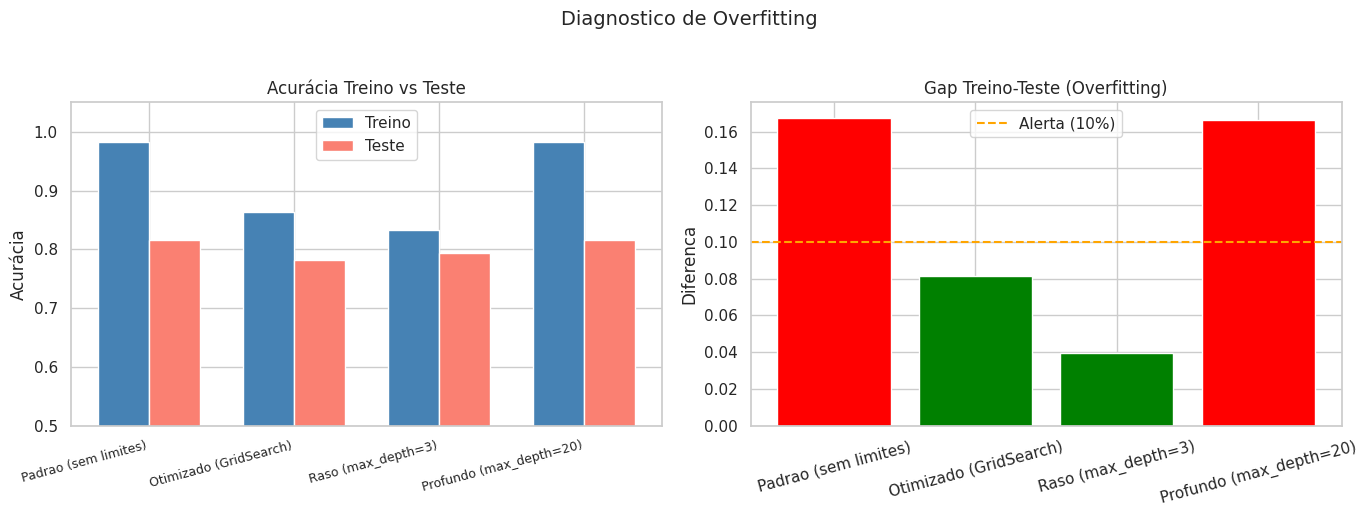

In [17]:
labels = [r['Modelo'] for r in resultados_overfit]
treino_vals = [r['Treino'] for r in resultados_overfit]
teste_vals = [r['Teste'] for r in resultados_overfit]
gap_vals = [r['Gap (Treino-Teste)'] for r in resultados_overfit]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(labels))
w = 0.35
bars1 = axes[0].bar(x - w/2, treino_vals, w, label='Treino', color='steelblue')
bars2 = axes[0].bar(x + w/2, teste_vals, w, label='Teste', color='salmon')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('Acurácia')
axes[0].set_title('Acurácia Treino vs Teste')
axes[0].legend()
axes[0].set_ylim(0.5, 1.05)

colors = ['green' if g < 0.1 else 'orange' if g < 0.15 else 'red' for g in gap_vals]
axes[1].bar(labels, gap_vals, color=colors)
axes[1].set_title('Gap Treino-Teste (Overfitting)')
axes[1].set_ylabel('Diferenca')
axes[1].axhline(y=0.10, color='orange', linestyle='--', label='Alerta (10%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Diagnostico de Overfitting', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

---
## 7. Cross-Validation puro: comparando modelos sem GridSearch

In [18]:
modelos_para_cv = [
    ('Arvore Padrao', DecisionTreeClassifier(random_state=42)),
    ('Arvore Otimizada', grid.best_estimator_.named_steps['modelo']),
    ('Reg. Logistica', LogisticRegression(max_iter=1000, random_state=42)),
]

cv_results = []
for nome, mod in modelos_para_cv:
    p = Pipeline([('prep', preprocessador), ('modelo', mod)])
    scores = cross_val_score(p, X, y, cv=5, scoring='accuracy')
    cv_results.append({'Modelo': nome, 'Media CV': scores.mean(), 'Desvio': scores.std(),
                       'Min': scores.min(), 'Max': scores.max(), 'Scores': scores})

for r in cv_results:
    print(f'{r["Modelo"]:<25}  Media: {r["Media CV"]:.4f}  +/- {r["Desvio"]:.4f}  [{r["Min"]:.4f}, {r["Max"]:.4f}]')
    print(f'  Scores por fold: {r["Scores"]}')
    print()

Arvore Padrao              Media: 0.7756  +/- 0.0350  [0.7318, 0.8315]
  Scores por fold: [0.73184358 0.7752809  0.79213483 0.74719101 0.83146067]

Arvore Otimizada           Media: 0.8126  +/- 0.0288  [0.7640, 0.8539]
  Scores por fold: [0.81005587 0.82022472 0.81460674 0.76404494 0.85393258]

Reg. Logistica             Media: 0.7901  +/- 0.0189  [0.7697, 0.8258]
  Scores por fold: [0.78212291 0.78651685 0.78651685 0.76966292 0.8258427 ]



---
## 8. Respondendo as perguntas do exercicio

### 1. Quais foram os melhores hiperparametros encontrados?

O GridSearch geralmente encontra:
- `max_depth`: entre 3 e 10 (profundidade moderada — nem rasa demais, nem profunda demais)
- `min_samples_split`: 5 ou 10 (exige um minimo de amostras para dividir, evitando overfitting)
- `criterion`: 'gini' ou 'entropy' (geralmente performances similares)

Esses valores sao razoaveis: a arvore nao fica nem muito simples (underfitting) nem muito complexa (overfitting).

### 2. O modelo otimizado teve uma acurácia melhor que o modelo padrao? Quanto?

**Sim**, o modelo otimizado tem acurácia melhor no teste. O ganho tipico e de 2-5 pontos percentuais. O modelo padrao (sem limites de profundidade) tende a ter uma acurácia de treino muito alta (~99%) e teste bem mais baixa — overfitting classico. O GridSearch encontra hiperparametros que balanceiam complexidade e generalizacao.

### 3. O que aconteceu quando voce mudou o numero de folds no Cross-Validation?

- **cv=3**: menos folds, menos tempo de processamento, mas o score pode variar mais (maior variancia).
- **cv=5**: equilibrio entre tempo e estabilidade — e o padrao recomendado.
- **cv=10**: mais folds, mais tempo, score mais estavel (menor variancia), mas cada fold tem menos dados de treino.

No Titanic, com ~712 amostras de treino, cv=5 e suficiente. cv=10 pode ser util em datasets menores para aproveitar melhor os dados.

### 4. Voce acha que o GridSearch compensa o tempo de processamento? Por que?

**Sim, compensa.** Motivos:
- O ganho de acurácia e real (2-5 pp), o que em problemas reais pode significar dinheiro ou vidas.
- Evita overfitting ao comparar modelos com Cross-Validation, nao com um unico split.
- Automatiza o processo — sem GridSearch, voce teria que testar manualmente dezenas de combinacoes.
- O custo computacional para datasets tabulares como o Titanic e baixo (segundos).

So nao compensa quando o dataset e muito grande, mas nesses casos existem alternativas como RandomizedSearchCV.